In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
loan_data = pd.read_csv('/content/loan_dataset.csv')

In [3]:
loan_data.head()

,loan_id,source,financial_institution,interest_rate,unpaid_principal_bal,loan_term,origination_date,first_payment_date,loan_to_value,number_of_borrowers,...,m4,m5,m6,m7,m8,m9,m10,m11,m12,m13
0,268055008619,Z,"Turner, Baldwin and Rhodes",4.250,214000,360,2012-03-01,05/2012,95,1.0,...,0,0,0,1,0,0,0,0,0,1
1,672831657627,Y,"Swanson, Newton and Miller",4.875,144000,360,2012-01-01,03/2012,72,1.0,...,0,0,0,0,0,0,0,1,0,1
2,742515242108,Z,Thornton-Davis,3.250,366000,180,2012-01-01,03/2012,49,1.0,...,0,0,0,0,0,0,0,0,0,1
3,601385667462,X,OTHER,4.750,135000,360,2012-02-01,04/2012,46,2.0,...,0,0,0,0,0,1,1,1,1,1
4,273870029961,X,OTHER,4.750,124000,360,2012-02-01,04/2012,80,1.0,...,3,4,5,6,7,8,9,10,11,1


In [4]:
loan_data.shape

(116058, 29)

In [5]:
loan_data.dtypes

,0
loan_id,int64
source,object
financial_institution,object
interest_rate,float64
unpaid_principal_bal,int64
loan_term,int64
origination_date,object
first_payment_date,object
loan_to_value,int64
number_of_borrowers,float64


In [6]:
loan_data.isna().sum()

,0
loan_id,0
source,0
financial_institution,0
interest_rate,0
unpaid_principal_bal,0
loan_term,0
origination_date,0
first_payment_date,0
loan_to_value,0
number_of_borrowers,0


In [7]:
loan_data.describe()

,loan_id,interest_rate,unpaid_principal_bal,loan_term,loan_to_value,number_of_borrowers,debt_to_income_ratio,borrower_credit_score,insurance_percent,co-borrower_credit_score,...,m4,m5,m6,m7,m8,m9,m10,m11,m12,m13
count,1.160580e+05,116058.000000,1.160580e+05,116058.000000,116058.000000,116058.000000,116058.000000,116058.000000,116058.000000,116058.000000,...,116058.000000,116058.000000,116058.000000,116058.000000,116058.000000,116058.000000,116058.000000,116058.000000,116058.000000,116058.000000
mean,5.494155e+11,3.868961,2.082262e+05,292.280997,67.431939,1.593186,30.742293,769.926778,2.786288,459.611565,...,0.002180,0.003533,0.003421,0.004162,0.004825,0.005359,0.006617,0.007109,0.008065,0.005480
std,2.597560e+11,0.461020,1.146851e+05,89.762415,17.291719,0.491242,9.730798,42.210706,8.096464,381.946926,...,0.062161,0.082638,0.087553,0.100961,0.113128,0.128242,0.148430,0.162884,0.178128,0.073824
min,1.000009e+11,2.250000,1.100000e+04,60.000000,6.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.244656e+11,3.500000,1.200000e+05,180.000000,57.000000,1.000000,23.000000,751.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.486239e+11,3.875000,1.830000e+05,360.000000,72.000000,2.000000,31.000000,782.000000,0.000000,740.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7.743034e+11,4.125000,2.780000e+05,360.000000,80.000000,2.000000,39.000000,800.000000,0.000000,791.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,9.999971e+11,6.750000,1.200000e+06,360.000000,97.000000,2.000000,64.000000,840.000000,40.000000,836.000000,...,6.000000,7.000000,8.000000,9.000000,10.000000,11.000000,12.000000,13.000000,14.000000,1.000000


In [8]:
loan_data.columns

Index(['loan_id', 'source', 'financial_institution', 'interest_rate',
       'unpaid_principal_bal', 'loan_term', 'origination_date',
       'first_payment_date', 'loan_to_value', 'number_of_borrowers',
       'debt_to_income_ratio', 'borrower_credit_score', 'loan_purpose',
       'insurance_percent', 'co-borrower_credit_score', 'insurance_type', 'm1',
       'm2', 'm3', 'm4', 'm5', 'm6', 'm7', 'm8', 'm9', 'm10', 'm11', 'm12',
       'm13'],
      dtype='object')

In [9]:
loan_data.duplicated().sum()

np.int64(0)

In [10]:
loan_data.index

RangeIndex(start=0, stop=116058, step=1)

## Outlier Handling

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, 'loan_id'),
  Text(1, 0, 'interest_rate'),
  Text(2, 0, 'unpaid_principal_bal'),
  Text(3, 0, 'loan_term'),
  Text(4, 0, 'loan_to_value'),
  Text(5, 0, 'number_of_borrowers'),
  Text(6, 0, 'debt_to_income_ratio'),
  Text(7, 0, 'borrower_credit_score'),
  Text(8, 0, 'insurance_percent'),
  Text(9, 0, 'co-borrower_credit_score'),
  Text(10, 0, 'insurance_type'),
  Text(11, 0, 'm1'),
  Text(12, 0, 'm2'),
  Text(13, 0, 'm3'),
  Text(14, 0, 'm4'),
  Text(15, 0, 'm5'),
  Text(16, 0, 'm6'),
  Text(17, 0, 'm7'),
  Text(18, 0, 'm8'),
  Text(19, 0, 'm9'),
  Text(20, 0, 'm10'),
  Text(21, 0, 'm11'),
  Text(22, 0, 'm12'),
  Text(23, 0, 'm13')])

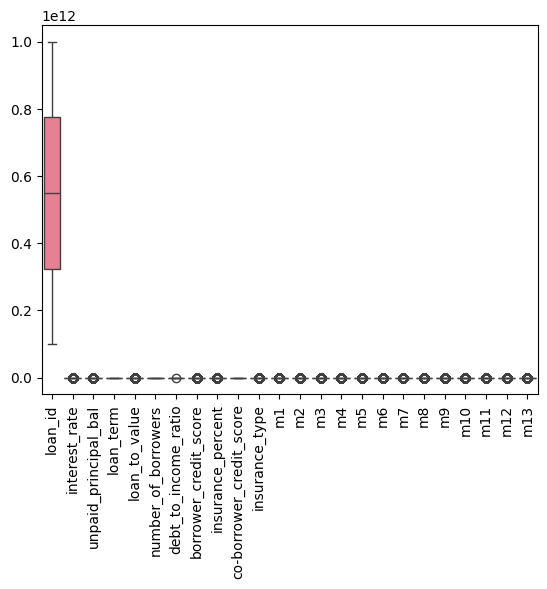

In [11]:
sns.boxplot(loan_data)
plt.xticks(rotation = 90)

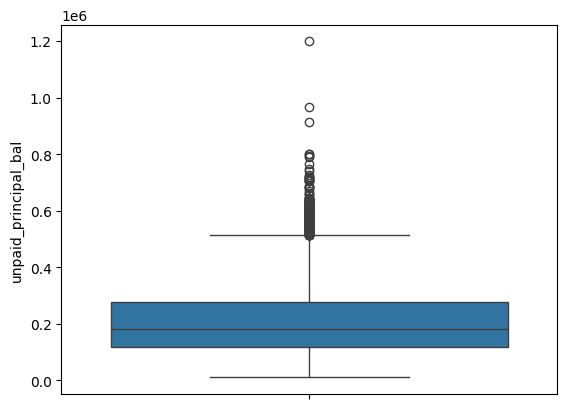

In [12]:
sns.boxplot(loan_data['unpaid_principal_bal'])
plt.show()

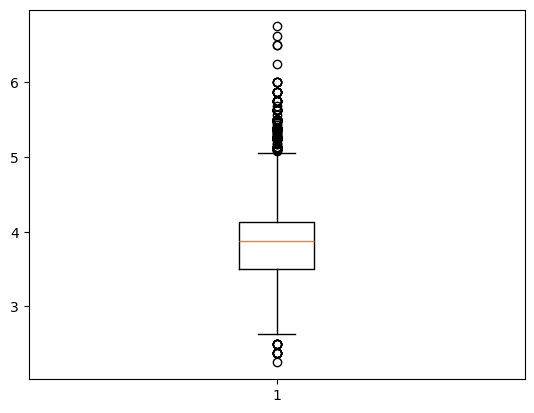

In [13]:
plt.boxplot(loan_data['interest_rate'])
plt.show()

#IQR method

In [14]:
# Handling outliers in IQR method
q1 = loan_data['interest_rate'].quantile(0.25)
q3 = loan_data['interest_rate'].quantile(0.75)
IQR = q3 - q1


In [15]:
print(f'Q1 = {q1}\nq3 = {q3}')

Q1 = 3.5
q3 = 4.125


In [16]:
iqr = q3 - q1
low_lim= q1 - 1.5 * IQR
up_lim = q3 + 1.5 * IQR
print(f'IQR = {iqr}\nUp_Lim = {up_lim}\nLow_Lim = {low_lim}')

IQR = 0.625
Up_Lim = 5.0625
Low_Lim = 2.5625


In [17]:
loan_data[loan_data['interest_rate'] > up_lim]

,loan_id,source,financial_institution,interest_rate,unpaid_principal_bal,loan_term,origination_date,first_payment_date,loan_to_value,number_of_borrowers,...,m4,m5,m6,m7,m8,m9,m10,m11,m12,m13
14,828404369124,Y,Edwards-Hoffman,5.125,84000,360,2012-02-01,04/2012,80,1.0,...,0,0,0,0,0,0,0,0,0,1
39,776153574210,X,"Swanson, Newton and Miller",5.500,42000,360,2012-01-01,03/2012,79,1.0,...,0,0,0,0,1,1,2,2,1,1
61,632078036699,X,"Miller, Mcclure and Allen",5.125,98000,360,2012-03-01,05/2012,35,1.0,...,0,0,0,0,0,0,0,0,1,1
73,992660230690,X,OTHER,5.250,64000,360,2012-01-01,03/2012,73,1.0,...,0,2,3,2,0,1,1,2,3,1
88,983776307873,Y,Browning-Hart,5.125,207000,360,2012-01-01,03/2012,75,1.0,...,0,0,0,1,2,3,4,5,6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115082,205273257268,X,OTHER,5.250,52000,360,2012-02-01,04/2012,80,1.0,...,0,0,0,0,0,0,0,0,0,0
115236,814809258851,X,"Swanson, Newton and Miller",5.125,50000,360,2012-01-01,03/2012,64,1.0,...,0,0,0,0,0,0,0,0,0,0
115487,755044946222,Y,Edwards-Hoffman,5.500,264000,360,2012-02-01,04/2012,80,2.0,...,0,0,0,0,0,0,0,0,0,0
115777,877439892785,Y,Browning-Hart,5.250,74000,360,2012-02-01,04/2012,80,2.0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
loan_data[loan_data['interest_rate'] < low_lim]

,loan_id,source,financial_institution,interest_rate,unpaid_principal_bal,loan_term,origination_date,first_payment_date,loan_to_value,number_of_borrowers,...,m4,m5,m6,m7,m8,m9,m10,m11,m12,m13
13394,701145052815,X,OTHER,2.375,153000,180,2012-02-01,04/2012,71,1.0,...,0,0,0,0,0,0,0,0,0,0
15473,630157427816,X,OTHER,2.500,75000,180,2012-01-01,03/2012,60,1.0,...,0,0,0,0,0,0,0,0,0,0
20669,805263353355,X,OTHER,2.375,91000,120,2012-02-01,04/2012,70,2.0,...,0,0,0,0,0,0,0,0,0,0
21160,334075716481,X,OTHER,2.500,67000,180,2012-01-01,03/2012,67,1.0,...,0,0,0,0,0,0,0,0,0,0
46017,277977244518,X,OTHER,2.375,135000,180,2012-01-01,03/2012,45,2.0,...,0,0,0,0,0,0,0,0,0,0
50884,346777228569,X,OTHER,2.500,173000,180,2012-02-01,04/2012,73,2.0,...,0,0,0,0,0,0,0,0,0,0
62401,832596321639,X,OTHER,2.500,179000,180,2012-02-01,04/2012,60,2.0,...,0,0,0,0,0,0,0,0,0,0
75162,944729656638,X,OTHER,2.375,91000,180,2012-01-01,03/2012,70,2.0,...,0,0,0,0,0,0,0,0,0,0
80701,364499070160,X,OTHER,2.375,120000,180,2012-01-01,03/2012,75,2.0,...,0,0,0,0,0,0,0,0,0,0
93537,282080446969,X,OTHER,2.500,201000,180,2012-02-01,04/2012,66,1.0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
loan_data[loan_data['interest_rate'] > up_lim].index

Index([    14,     39,     61,     73,     88,    120,    122,    124,    132,
          146,
       ...
       114512, 114611, 114661, 114793, 114909, 115082, 115236, 115487, 115777,
       115861],
      dtype='int64', length=922)

In [20]:
loan_data.loc[loan_data['interest_rate'] > up_lim, 'interest_rate'] = up_lim
loan_data.loc[loan_data['interest_rate'] < low_lim, 'interest_rate'] = low_lim

In [21]:
outliers = loan_data[(loan_data['interest_rate'] > up_lim) | (
    loan_data['interest_rate'] < low_lim
)]

In [22]:
outliers

,loan_id,source,financial_institution,interest_rate,unpaid_principal_bal,loan_term,origination_date,first_payment_date,loan_to_value,number_of_borrowers,...,m4,m5,m6,m7,m8,m9,m10,m11,m12,m13


In [23]:
q1 = loan_data['unpaid_principal_bal'].quantile(0.25)
q3 = loan_data['unpaid_principal_bal'].quantile(0.75)
IQR = q3 - q1

In [24]:
print(f'Q1 = {q1}\nq3 = {q3}')

Q1 = 120000.0
q3 = 278000.0


In [25]:
iqr = q3 - q1
low_lim= q1 - 1.5 * IQR
up_lim = q3 + 1.5 * IQR
print(f'IQR = {iqr}\nUp_Lim = {up_lim}\nLow_Lim = {low_lim}')

IQR = 158000.0
Up_Lim = 515000.0
Low_Lim = -117000.0


In [26]:
loan_data[loan_data['unpaid_principal_bal'] > up_lim]

,loan_id,source,financial_institution,interest_rate,unpaid_principal_bal,loan_term,origination_date,first_payment_date,loan_to_value,number_of_borrowers,...,m4,m5,m6,m7,m8,m9,m10,m11,m12,m13
8,423590072335,X,Browning-Hart,4.000,520000,360,2012-03-01,05/2012,76,1.0,...,0,1,0,1,0,1,2,0,1,1
34,334480445422,Z,Edwards-Hoffman,4.312,588000,360,2012-01-01,03/2012,80,1.0,...,0,0,0,0,0,0,0,1,1,1
175,398583122496,X,OTHER,4.250,610000,360,2012-01-01,03/2012,89,1.0,...,0,0,1,1,0,0,1,0,1,1
365,200594099596,Z,Nicholson Group,4.500,590000,360,2012-02-01,04/2012,67,1.0,...,0,0,0,0,0,0,0,0,0,1
491,156288412080,X,OTHER,4.250,520000,360,2012-03-01,05/2012,77,2.0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115843,759955797009,Y,Browning-Hart,4.375,546000,360,2012-01-01,03/2012,73,1.0,...,0,0,0,0,0,0,0,0,0,0
115847,926820512067,Y,Browning-Hart,4.375,570000,360,2012-02-01,04/2012,70,2.0,...,0,0,0,0,0,0,0,0,0,0
115940,268431394219,Y,Browning-Hart,4.250,519000,360,2012-01-01,03/2012,76,2.0,...,0,0,0,0,0,0,0,0,0,0
115963,151300800839,Y,Browning-Hart,3.250,580000,180,2012-02-01,04/2012,70,2.0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
loan_data[loan_data['unpaid_principal_bal'] < low_lim]

,loan_id,source,financial_institution,interest_rate,unpaid_principal_bal,loan_term,origination_date,first_payment_date,loan_to_value,number_of_borrowers,...,m4,m5,m6,m7,m8,m9,m10,m11,m12,m13


In [28]:
loan_data.loc[loan_data['unpaid_principal_bal'] > up_lim, 'unpaid_principal_bal'] = up_lim
loan_data.loc[loan_data['unpaid_principal_bal'] < low_lim, 'unpaid_principal_bal'] = low_lim

In [29]:
outliers = loan_data[(loan_data['unpaid_principal_bal'] > up_lim) | (
    loan_data['unpaid_principal_bal'] < low_lim
)]

In [30]:
outliers

,loan_id,source,financial_institution,interest_rate,unpaid_principal_bal,loan_term,origination_date,first_payment_date,loan_to_value,number_of_borrowers,...,m4,m5,m6,m7,m8,m9,m10,m11,m12,m13


In [31]:
loan_data.head()

,loan_id,source,financial_institution,interest_rate,unpaid_principal_bal,loan_term,origination_date,first_payment_date,loan_to_value,number_of_borrowers,...,m4,m5,m6,m7,m8,m9,m10,m11,m12,m13
0,268055008619,Z,"Turner, Baldwin and Rhodes",4.250,214000,360,2012-03-01,05/2012,95,1.0,...,0,0,0,1,0,0,0,0,0,1
1,672831657627,Y,"Swanson, Newton and Miller",4.875,144000,360,2012-01-01,03/2012,72,1.0,...,0,0,0,0,0,0,0,1,0,1
2,742515242108,Z,Thornton-Davis,3.250,366000,180,2012-01-01,03/2012,49,1.0,...,0,0,0,0,0,0,0,0,0,1
3,601385667462,X,OTHER,4.750,135000,360,2012-02-01,04/2012,46,2.0,...,0,0,0,0,0,1,1,1,1,1
4,273870029961,X,OTHER,4.750,124000,360,2012-02-01,04/2012,80,1.0,...,3,4,5,6,7,8,9,10,11,1


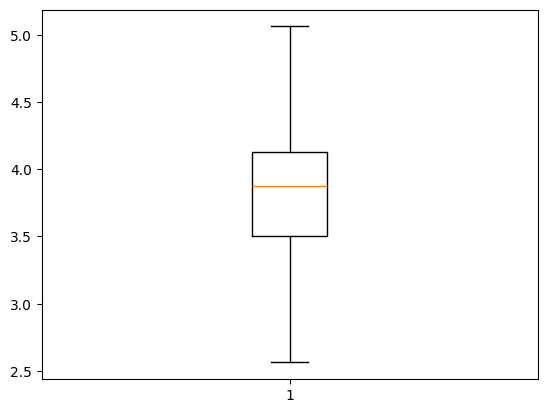

In [32]:
# After Outliers
plt.boxplot(loan_data['interest_rate'])
plt.show()

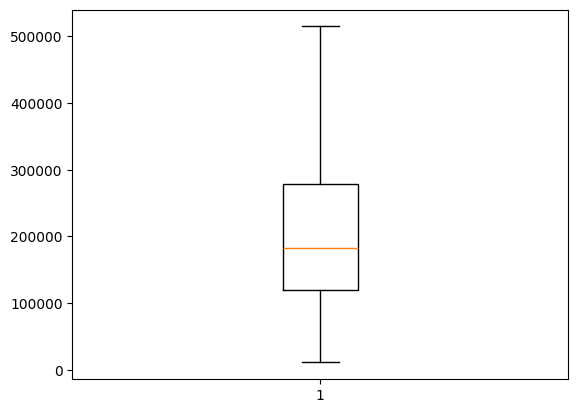

In [33]:
plt.boxplot(loan_data['unpaid_principal_bal'])
plt.show()

# Encoding

In [34]:
loan_data.dtypes

,0
loan_id,int64
source,object
financial_institution,object
interest_rate,float64
unpaid_principal_bal,int64
loan_term,int64
origination_date,object
first_payment_date,object
loan_to_value,int64
number_of_borrowers,float64


In [35]:
# 1. Base Setup: Define x, x1, and y from your dataset
x = loan_data.drop('m13', axis=1)
x1 = x.copy()  # Defines x1 so it is ready to use
y = loan_data['m13']

# 2. Encode Categorical Data into Numbers (One-Hot Encoding)
# Identifies columns with text/categories and converts them to 0s and 1s
cat_cols = x1.select_dtypes(include=['object', 'category']).columns
x1 = pd.get_dummies(x1, columns=cat_cols, drop_first=True)

In [36]:
loan_data = pd.get_dummies(loan_data,dtype='int',drop_first = True)

In [37]:
loan_data

,loan_id,interest_rate,unpaid_principal_bal,loan_term,loan_to_value,number_of_borrowers,debt_to_income_ratio,borrower_credit_score,insurance_percent,co-borrower_credit_score,...,"financial_institution_Taylor, Hunt and Rodriguez",financial_institution_Thornton-Davis,"financial_institution_Turner, Baldwin and Rhodes",origination_date_2012-02-01,origination_date_2012-03-01,first_payment_date_03/2012,first_payment_date_04/2012,first_payment_date_05/2012,loan_purpose_B12,loan_purpose_C86
0,268055008619,4.250,214000,360,95,1.0,22.0,694.0,30.0,0.0,...,0,0,1,0,1,0,0,1,0,1
1,672831657627,4.875,144000,360,72,1.0,44.0,697.0,0.0,0.0,...,0,0,0,0,0,1,0,0,1,0
2,742515242108,3.250,366000,180,49,1.0,33.0,780.0,0.0,0.0,...,0,1,0,0,0,1,0,0,1,0
3,601385667462,4.750,135000,360,46,2.0,44.0,633.0,0.0,638.0,...,0,0,0,1,0,0,1,0,1,0
4,273870029961,4.750,124000,360,80,1.0,43.0,681.0,0.0,0.0,...,0,0,0,1,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116053,382119962287,4.125,153000,360,88,2.0,22.0,801.0,25.0,802.0,...,0,0,0,1,0,0,1,0,0,0
116054,582803915466,3.000,150000,120,35,1.0,37.0,796.0,0.0,0.0,...,0,0,0,0,0,1,0,0,1,0
116055,837922316947,3.875,166000,360,58,2.0,49.0,724.0,0.0,723.0,...,0,0,0,1,0,0,1,0,1,0
116056,477343182138,4.250,169000,360,74,2.0,13.0,755.0,0.0,746.0,...,0,0,0,1,0,0,1,0,0,0


In [38]:
loan_data['m13']

,m13
0,1
1,1
2,1
3,1
4,1
...,...
116053,0
116054,0
116055,0
116056,0


In [39]:
# non scaled x_train and x_test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [40]:
# non scaled x_train and x_test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [41]:
x_train.head()

,loan_id,source,financial_institution,interest_rate,unpaid_principal_bal,loan_term,origination_date,first_payment_date,loan_to_value,number_of_borrowers,...,m3,m4,m5,m6,m7,m8,m9,m10,m11,m12
38253,102431034835,X,"Swanson, Newton and Miller",3.750,159000,180,2012-02-01,04/2012,68,1.0,...,0,0,0,0,0,0,0,0,0,0
15259,867835396575,X,"Romero, Woods and Johnson",3.500,155000,180,2012-01-01,03/2012,69,2.0,...,0,0,0,0,0,0,0,0,0,0
87865,508543738726,X,OTHER,4.250,280000,360,2012-02-01,04/2012,75,1.0,...,0,0,0,0,0,0,0,0,0,0
47293,115397290915,X,OTHER,3.700,40000,240,2012-03-01,04/2012,24,2.0,...,0,0,0,0,0,0,0,0,0,0
10780,807427815303,X,OTHER,3.875,174000,240,2012-01-01,03/2012,70,2.0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
x1.head()

,loan_id,interest_rate,unpaid_principal_bal,loan_term,loan_to_value,number_of_borrowers,debt_to_income_ratio,borrower_credit_score,insurance_percent,co-borrower_credit_score,...,"financial_institution_Taylor, Hunt and Rodriguez",financial_institution_Thornton-Davis,"financial_institution_Turner, Baldwin and Rhodes",origination_date_2012-02-01,origination_date_2012-03-01,first_payment_date_03/2012,first_payment_date_04/2012,first_payment_date_05/2012,loan_purpose_B12,loan_purpose_C86
0,268055008619,4.250,214000,360,95,1.0,22.0,694.0,30.0,0.0,...,False,False,True,False,True,False,False,True,False,True
1,672831657627,4.875,144000,360,72,1.0,44.0,697.0,0.0,0.0,...,False,False,False,False,False,True,False,False,True,False
2,742515242108,3.250,366000,180,49,1.0,33.0,780.0,0.0,0.0,...,False,True,False,False,False,True,False,False,True,False
3,601385667462,4.750,135000,360,46,2.0,44.0,633.0,0.0,638.0,...,False,False,False,True,False,False,True,False,True,False
4,273870029961,4.750,124000,360,80,1.0,43.0,681.0,0.0,0.0,...,False,False,False,True,False,False,True,False,False,True


In [43]:
categorical_cols = x1.select_dtypes(include=['object', 'category']).columns
categorical_cols

Index([], dtype='object')

In [44]:
# DEFINE YOUR ORDINAL COLUMNS AND THEIR EXACT ORDER

ordinal_cols = ['education', 'risk_level']
categories_order = [
    ['High School', 'Undergraduate', 'Postgraduate'],  # Order for 'education'
    ['Low', 'Medium', 'High']]                         # Order for 'risk_level'

In [45]:
ordinal_cols

['education', 'risk_level']

#  Label Encoding

In [46]:
from sklearn.preprocessing import LabelEncoder

In [47]:
le = LabelEncoder()
y = le.fit_transform(y)
y = pd.DataFrame(y, columns = ['m13'])

In [48]:
x

,loan_id,source,financial_institution,interest_rate,unpaid_principal_bal,loan_term,origination_date,first_payment_date,loan_to_value,number_of_borrowers,...,m3,m4,m5,m6,m7,m8,m9,m10,m11,m12
0,268055008619,Z,"Turner, Baldwin and Rhodes",4.250,214000,360,2012-03-01,05/2012,95,1.0,...,0,0,0,0,1,0,0,0,0,0
1,672831657627,Y,"Swanson, Newton and Miller",4.875,144000,360,2012-01-01,03/2012,72,1.0,...,0,0,0,0,0,0,0,0,1,0
2,742515242108,Z,Thornton-Davis,3.250,366000,180,2012-01-01,03/2012,49,1.0,...,0,0,0,0,0,0,0,0,0,0
3,601385667462,X,OTHER,4.750,135000,360,2012-02-01,04/2012,46,2.0,...,0,0,0,0,0,0,1,1,1,1
4,273870029961,X,OTHER,4.750,124000,360,2012-02-01,04/2012,80,1.0,...,2,3,4,5,6,7,8,9,10,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116053,382119962287,Y,Browning-Hart,4.125,153000,360,2012-02-01,04/2012,88,2.0,...,0,0,0,0,0,0,0,0,0,0
116054,582803915466,Z,OTHER,3.000,150000,120,2012-01-01,03/2012,35,1.0,...,0,0,0,0,0,0,0,0,0,0
116055,837922316947,X,OTHER,3.875,166000,360,2012-02-01,04/2012,58,2.0,...,0,0,0,0,0,0,0,0,0,0
116056,477343182138,X,OTHER,4.250,169000,360,2012-02-01,04/2012,74,2.0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
y

,m13
0,1
1,1
2,1
3,1
4,1
...,...
116053,0
116054,0
116055,0
116056,0


In [50]:
x.head()

,loan_id,source,financial_institution,interest_rate,unpaid_principal_bal,loan_term,origination_date,first_payment_date,loan_to_value,number_of_borrowers,...,m3,m4,m5,m6,m7,m8,m9,m10,m11,m12
0,268055008619,Z,"Turner, Baldwin and Rhodes",4.250,214000,360,2012-03-01,05/2012,95,1.0,...,0,0,0,0,1,0,0,0,0,0
1,672831657627,Y,"Swanson, Newton and Miller",4.875,144000,360,2012-01-01,03/2012,72,1.0,...,0,0,0,0,0,0,0,0,1,0
2,742515242108,Z,Thornton-Davis,3.250,366000,180,2012-01-01,03/2012,49,1.0,...,0,0,0,0,0,0,0,0,0,0
3,601385667462,X,OTHER,4.750,135000,360,2012-02-01,04/2012,46,2.0,...,0,0,0,0,0,0,1,1,1,1
4,273870029961,X,OTHER,4.750,124000,360,2012-02-01,04/2012,80,1.0,...,2,3,4,5,6,7,8,9,10,11


MinMax  Scaler

In [51]:
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler()


#Logistic Regression

In [52]:
from sklearn.metrics import confusion_matrix,precision_score
from sklearn.metrics import  accuracy_score, f1_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix

In [53]:
from sklearn.linear_model import LogisticRegression

In [54]:
x = pd.get_dummies(x, drop_first=True, dtype=int)

In [55]:
import warnings
warnings.filterwarnings('ignore')
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [56]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(x_train,y_train)
y_pred_lr_model = lr_model.predict(x_test)
print('Accuracy is:', accuracy_score(y_test,y_pred_lr_model))
print('Precision is:', precision_score(y_test,y_pred_lr_model))
print('Recall is:', recall_score(y_test,y_pred_lr_model))
print('f1_score is:', f1_score(y_test,y_pred_lr_model))
print(confusion_matrix(y_test,y_pred_lr_model))

Accuracy is: 0.9945286920558332
Precision is: 0.0
Recall is: 0.0
f1_score is: 0.0
[[23085     0]
 [  127     0]]


# KNN

In [57]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
acc_score = []

for k in range(1, 40):
    neigh = KNeighborsClassifier(n_neighbors = k)
    neigh.fit(x_train, y_train)
    y_pred = neigh.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    acc_score.append(acc)

In [ ]:
acc_score

In [ ]:
plt.plot(range(1, 40), acc_score)
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.grid()

#SVM

In [ ]:
from sklearn.svm import SVC

In [ ]:
#linear kernal
svm_linear =  SVC(kernel = 'linear')
svm_linear.fit(x_train,y_train)
y_pred_svm_linear = svm_linear.predict(x_test)
print(confusion_matrix(y_test,y_pred_svm_linear))
print('Accuracy is : ',accuracy_score(y_test,y_pred_svm_linear))
print('Precision is : ',precision_score(y_test,y_pred_svm_linear))
print('Recall is : ',recall_score(y_test,y_pred_svm_linear))
print('F1 score is : ',f1_score(y_test,y_pred_svm_linear))

In [ ]:
#polynomial kernal
svm_poly =  SVC(kernel = 'poly')
svm_poly.fit(x_train1,y_train)
y_pred_svm_poly = svm_poly.predict(x_test1)
print(confusion_matrix(y_test,y_pred_svm_poly))
print('Accuracy is : ',accuracy_score(y_test,y_pred_svm_poly))
print('Precision is : ',precision_score(y_test,y_pred_svm_poly))
print('Recall is : ',recall_score(y_test,y_pred_svm_poly))
print('F1 score is : ',f1_score(y_test,y_pred_svm_poly))

#Decision tree

In [ ]:
# Decision tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='entropy',random_state= 42)
dt.fit(x_train,y_train)
y_pred_dt = dt.predict(x_test)
print(confusion_matrix(y_test,y_pred_dt))
print('Accuracy is : ',accuracy_score(y_test,y_pred_dt))
print('Precision is : ',precision_score(y_test,y_pred_dt))
print('Recall is : ',recall_score(y_test,y_pred_dt))
print('F1 score is : ',f1_score(y_test,y_pred_dt))

In [ ]:
# Adaboosting
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
adaboost_clf = AdaBoostClassifier(random_state=42)
adaboost_clf.fit(x_train,y_train)
y_pred_adaboost = adaboost_clf.predict(x_test)
print('Accuracy =',accuracy_score(y_test,y_pred_adaboost))
print('Precision=',precision_score(y_test,y_pred_adaboost))
print('Recall=',recall_score(y_test,y_pred_adaboost))
print('f1 score=',f1_score(y_test,y_pred_adaboost))
print(confusion_matrix(y_test,y_pred_adaboost))

In [ ]:
#Gradient Boost
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
gradboost_clf = GradientBoostingClassifier(random_state=42)
gradboost_clf.fit(x_train,y_train)
y_pred_gradboost = gradboost_clf.predict(x_test)
print('Accuracy =',accuracy_score(y_test,y_pred_gradboost))
print('Precision=',precision_score(y_test,y_pred_gradboost))
print('Recall=',recall_score(y_test,y_pred_gradboost))
print('f1 score=',f1_score(y_test,y_pred_gradboost))
print(confusion_matrix(y_test,y_pred_gradboost))

In [ ]:
#XG Boostin
import xgboost as xgb

In [ ]:
xgboost_clf = xgb.XGBClassifier()
xgboost_clf.fit(x_train,y_train)
y_pred_xgboost = xgboost_clf.predict(x_test)
print('Accuracy =',accuracy_score(y_test,y_pred_xgboost))
print('Precision=',precision_score(y_test,y_pred_xgboost))
print('Recall=',recall_score(y_test,y_pred_xgboost))
print('f1 score=',f1_score(y_test,y_pred_xgboost))
print(confusion_matrix(y_test,y_pred_xgboost))